In [1]:
# Name: Dhruv Kumar
# Roll No.: 24419CMP011
# Course: M.Sc. Computer Science
# Semester: 2nd

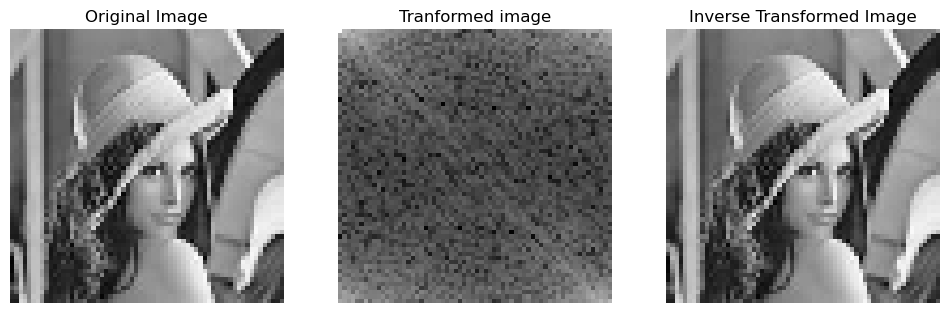

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def read_img(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError("Image not found")
    return cv2.resize(img, (64, 64))  

def dft2d(img):
    M, N = img.shape
    dft = np.zeros((M, N), dtype=complex)
    for u in range(M):
        for v in range(N):
            sum_val = 0
            for x in range(M):
                for y in range(N):
                    e = np.exp(-2j * np.pi * ((u*x)/M + (v*y)/N))
                    sum_val += img[x, y] * e
            dft[u, v] = sum_val
    return dft

def idft2d(dft):
    M, N = dft.shape
    img_recon = np.zeros((M, N), dtype=complex)
    for x in range(M):
        for y in range(N):
            sum_val = 0
            for u in range(M):
                for v in range(N):
                    e = np.exp(2j * np.pi * ((u*x)/M + (v*y)/N))
                    sum_val += dft[u, v] * e
            img_recon[x, y] = sum_val / (M * N)
    return np.abs(img_recon).astype(np.uint8)

def plot_images(original, magnitude, reconstructed):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(np.log(1 + np.abs(magnitude)), cmap='gray')
    plt.title("Tranformed image")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(reconstructed, cmap='gray')
    plt.title("Inverse Transformed Image")
    plt.axis('off')

    plt.show()

def main():
    img = read_img("D:\\Code\\Lenna.jpeg")
    dft = dft2d(img)
    reconstructed_img = idft2d(dft)
    plot_images(img, dft, reconstructed_img)

if __name__ == "__main__":
    main()

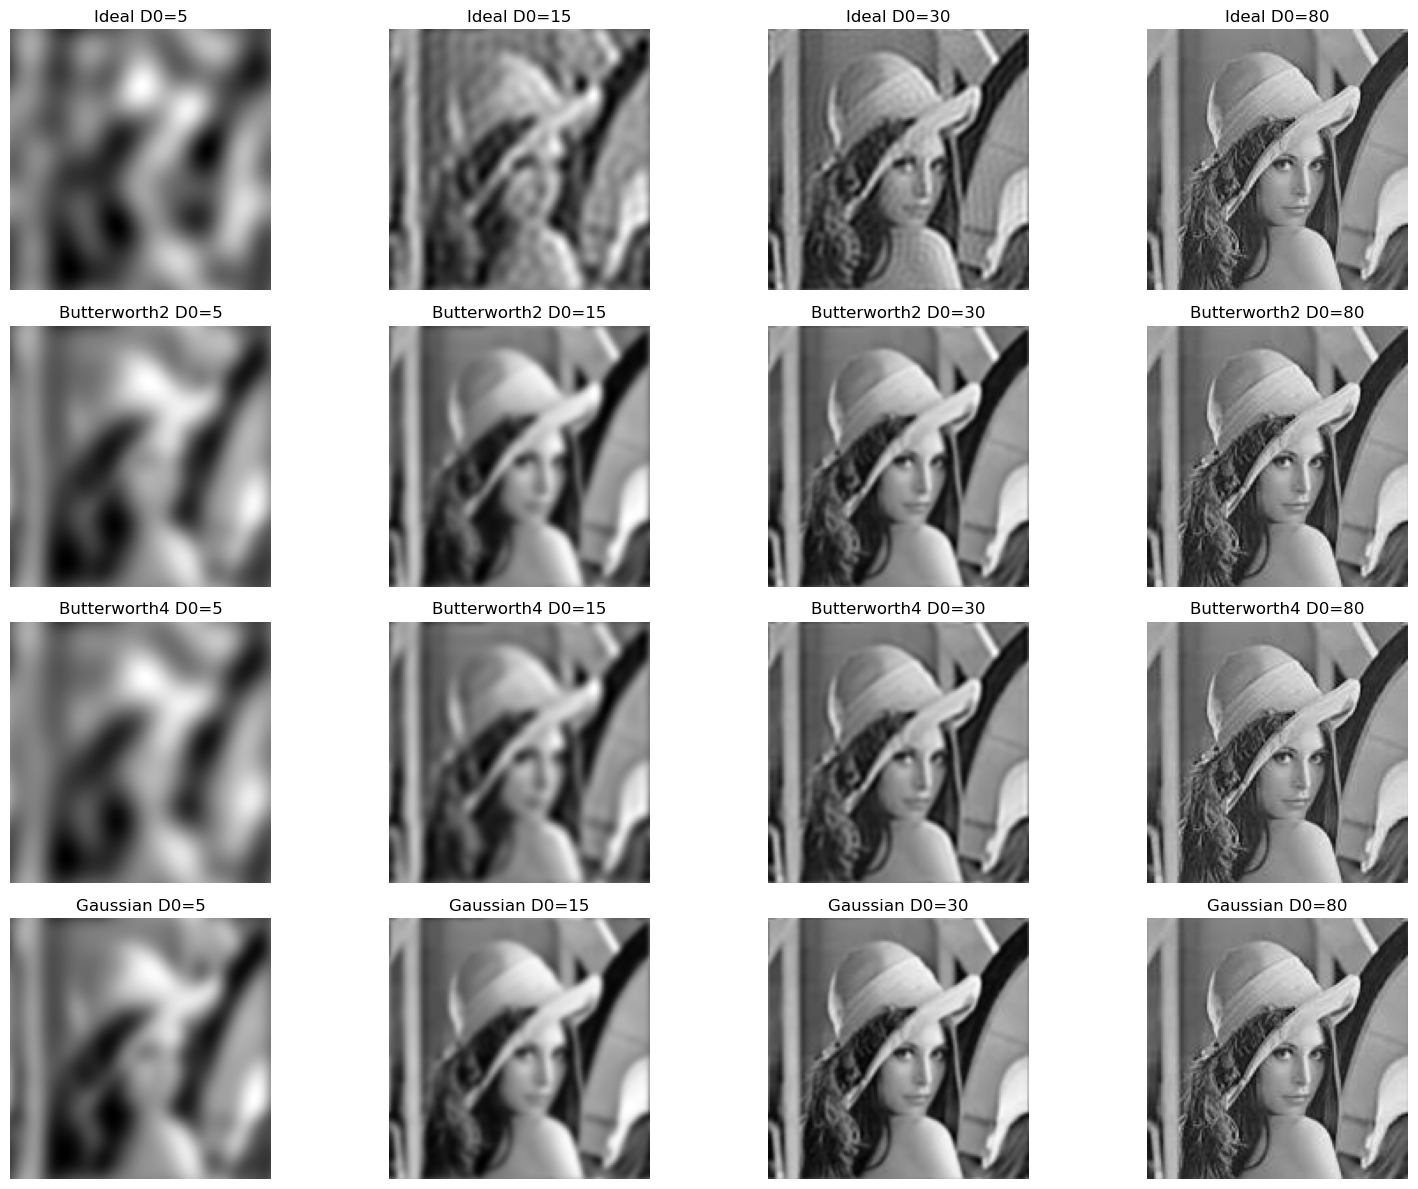

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def fft_image(image):
    return np.fft.fftshift(np.fft.fft2(image))

def ifft_image(f_image):
    return np.abs(np.fft.ifft2(np.fft.ifftshift(f_image)))

def distance_matrix(image):
    rows, cols = image.shape
    center = (rows // 2, cols // 2)
    D = np.zeros((rows, cols))
    for u in range(rows):
        for v in range(cols):
            D[u, v] = np.sqrt((u - center[0])**2 + (v - center[1])**2)
    return D

def ideal_low_pass(D, D0):
    H = np.zeros_like(D)
    H[D <= D0] = 1
    return H

def butterworth_low_pass(D, D0, order):
    return 1 / (1 + (D / D0)**(2 * order))

def gaussian_low_pass(D, D0):
    return np.exp(-(D**2) / (2 * D0**2))

def apply_filter(image, H):
    F = fft_image(image)
    G = F * H
    return ifft_image(G)

def main():
    img = cv2.imread("D:\\Code\\lenna.jpeg", cv2.IMREAD_GRAYSCALE).astype(np.float32)
    
    D = distance_matrix(img)
    
    D0_values = [5, 15, 30, 80]

    plt.figure(figsize=(16, 12))

    for i in range(4):
        D0 = D0_values[i]
        H = ideal_low_pass(D, D0)
        result = apply_filter(img, H)
        plt.subplot(4, 4, i + 1)
        plt.imshow(result, cmap='gray')
        plt.title(f'Ideal D0={D0}')
        plt.axis('off')

    for i in range(4):
        D0 = D0_values[i]
        H = butterworth_low_pass(D, D0, 2)
        result = apply_filter(img, H)
        plt.subplot(4, 4, 4 + i + 1)
        plt.imshow(result, cmap='gray')
        plt.title(f'Butterworth2 D0={D0}')
        plt.axis('off')

    for i in range(4):
        D0 = D0_values[i]
        H = butterworth_low_pass(D, D0, 4)
        result = apply_filter(img, H)
        plt.subplot(4, 4, 8 + i + 1)
        plt.imshow(result, cmap='gray')
        plt.title(f'Butterworth4 D0={D0}')
        plt.axis('off')

    for i in range(4):
        D0 = D0_values[i]
        H = gaussian_low_pass(D, D0)
        result = apply_filter(img, H)
        plt.subplot(4, 4, 12 + i + 1)
        plt.imshow(result, cmap='gray')
        plt.title(f'Gaussian D0={D0}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

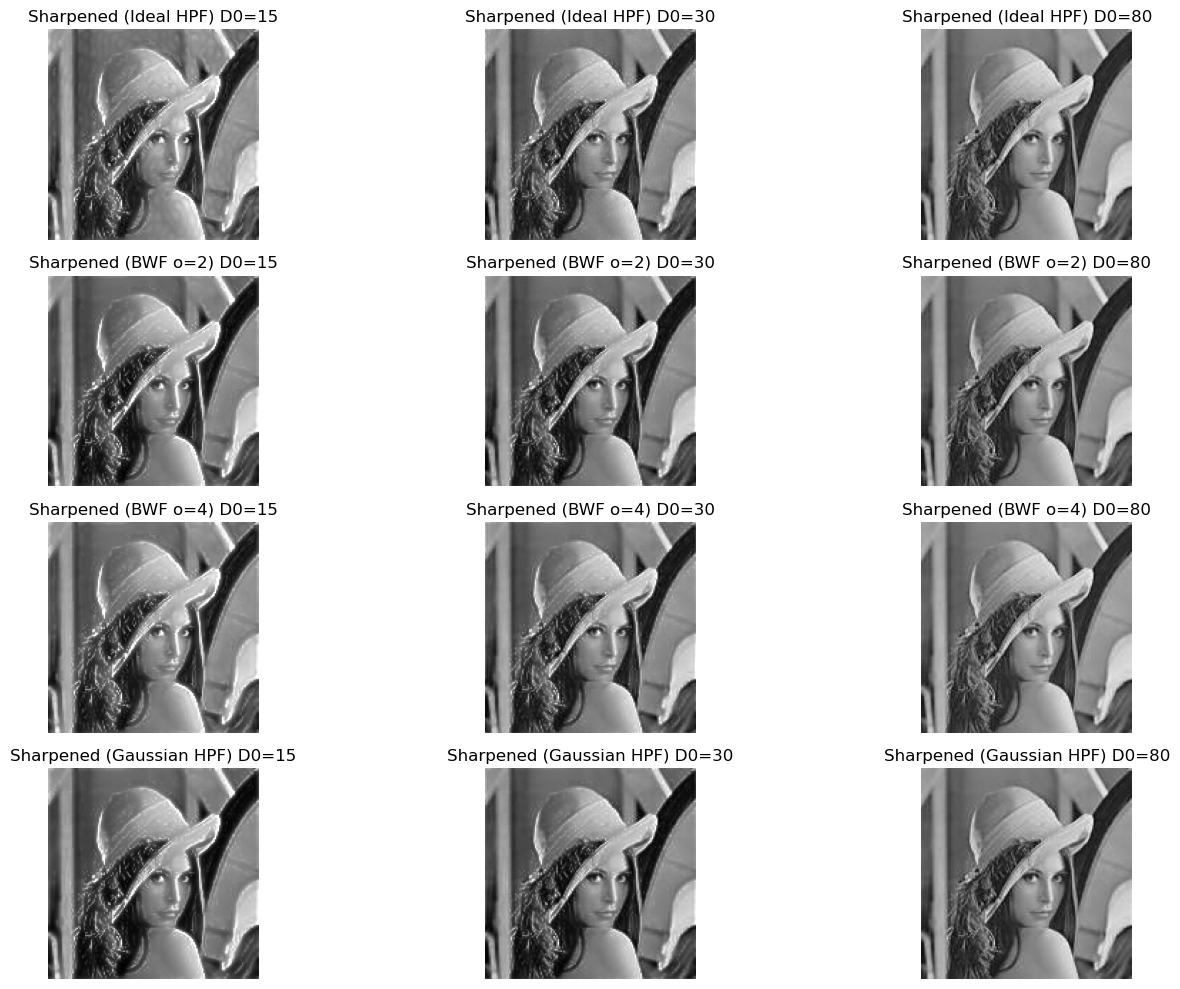

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def fft_image(image):
    return np.fft.fftshift(np.fft.fft2(image))

def ifft_image(f_image):
    return np.abs(np.fft.ifft2(np.fft.ifftshift(f_image)))

def distance_matrix(image):
    rows, cols = image.shape
    center = (rows // 2, cols // 2)
    D = np.zeros((rows, cols))
    for u in range(rows):
        for v in range(cols):
            D[u, v] = np.sqrt((u - center[0])**2 + (v - center[1])**2)
    return D

def ideal_high_pass(D, D0):
    H = np.ones_like(D)
    H[D <= D0] = 0
    return H

def butterworth_high_pass(D, D0, order):
    return 1 / (1 + (D0 / (D + 1e-5))**(2 * order))

def gaussian_high_pass(D, D0):
    return 1 - np.exp(-(D**2) / (2 * D0**2))

def apply_filter(image, H):
    F = fft_image(image)
    G = F * H
    return ifft_image(G)

def sharpen(image, high_pass_result, alpha=1.0):
    result = image + alpha * high_pass_result
    return np.clip(result, 0, 255)

def main():
    img = cv2.imread("D:\\Code\\lenna.jpeg", cv2.IMREAD_GRAYSCALE).astype(np.float32)
    D = distance_matrix(img)
    D0_values = [15, 30, 80]

    plt.figure(figsize=(15, 10))
    row = 1

    for i in range(3):
        D0 = D0_values[i]
        H = ideal_high_pass(D, D0)
        hp = apply_filter(img, H)
        result = sharpen(img, hp)
        plt.subplot(4, 3, row)
        plt.imshow(result, cmap='gray')
        plt.title(f'Sharpened (Ideal HPF) D0={D0}')
        plt.axis('off')
        row += 1

    for i in range(3):
        D0 = D0_values[i]
        H = butterworth_high_pass(D, D0, 2)
        hp = apply_filter(img, H)
        result = sharpen(img, hp)
        plt.subplot(4, 3, row)
        plt.imshow(result, cmap='gray')
        plt.title(f'Sharpened (BWF o=2) D0={D0}')
        plt.axis('off')
        row += 1

    for i in range(3):
        D0 = D0_values[i]
        H = butterworth_high_pass(D, D0, 4)
        hp = apply_filter(img, H)
        result = sharpen(img, hp)
        plt.subplot(4, 3, row)
        plt.imshow(result, cmap='gray')
        plt.title(f'Sharpened (BWF o=4) D0={D0}')
        plt.axis('off')
        row += 1

    for i in range(3):
        D0 = D0_values[i]
        H = gaussian_high_pass(D, D0)
        hp = apply_filter(img, H)
        result = sharpen(img, hp)
        plt.subplot(4, 3, row)
        plt.imshow(result, cmap='gray')
        plt.title(f'Sharpened (Gaussian HPF) D0={D0}')
        plt.axis('off')
        row += 1

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

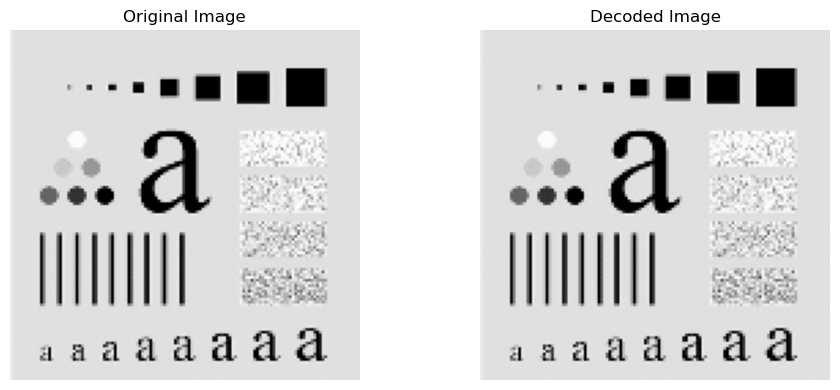

Compression Ratio: 1.93


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Node class for the Huffman tree
class Node:
    def __init__(self, symbol, freq):
        self.symbol = symbol
        self.freq = freq
        self.left = None
        self.right = None

# build Huffman tree
def build_huffman_tree(freq_dict):
    nodes = [Node(symbol, freq) for symbol, freq in freq_dict.items()]
    while len(nodes) > 1:
        # Sort by frequency
        for i in range(len(nodes)):
            for j in range(i + 1, len(nodes)):
                if nodes[i].freq > nodes[j].freq:
                    nodes[i], nodes[j] = nodes[j], nodes[i]

        left = nodes.pop(0)
        right = nodes.pop(0)
        merged = Node(None, left.freq + right.freq)
        merged.left = left
        merged.right = right
        nodes.append(merged)
    return nodes[0]

# Generate Huffman codes
def generate_codes(node, current_code, code_dict):
    if node is None:
        return
    if node.symbol is not None:
        code_dict[node.symbol] = current_code
    generate_codes(node.left, current_code + '0', code_dict)
    generate_codes(node.right, current_code + '1', code_dict)

# Encode image using Huffman coding
def huffman_encode(img, code_dict):
    huffman_data = ""
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            pixel = img[i][j]
            huffman_data += code_dict[pixel]
    return huffman_data

# Decode Huffman encoded data
def huffman_decode(huffman_data, root, shape):
    decoded_img = np.zeros(shape, dtype=np.uint8)
    i = 0
    current = root
    row = col = 0
    for bit in huffman_data:
        if bit == '0':
            current = current.left
        else:
            current = current.right
        if current.symbol is not None:
            decoded_img[row][col] = current.symbol
            col += 1
            if col == shape[1]:
                col = 0
                row += 1
            current = root
        i += 1
        if row == shape[0]:
            break
    return decoded_img

# Calculate frequency of each pixel
def calculate_frequency(img):
    freq = {}
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            val = img[i][j]
            if val not in freq:
                freq[val] = 1
            else:
                freq[val] += 1
    return freq

# Calculate compression ratio
def calculate_compression_ratio(img, huffman_data):
    original_bits = img.size * 8
    compressed_bits = len(huffman_data)
    ratio = original_bits / compressed_bits if compressed_bits != 0 else 0
    return ratio

img = cv2.imread("D:\\Code\\test_img.png", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (128, 128))

freq_dict = calculate_frequency(img)
root = build_huffman_tree(freq_dict)
code_dict = {}
generate_codes(root, "", code_dict)
huffman_data = huffman_encode(img, code_dict)
decoded_img = huffman_decode(huffman_data, root, img.shape)
compression_ratio = calculate_compression_ratio(img, huffman_data)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(decoded_img, cmap='gray')
axes[1].set_title("Decoded Image")
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Compression Ratio: {compression_ratio:.2f}")

Compression Ratio: 24525.00


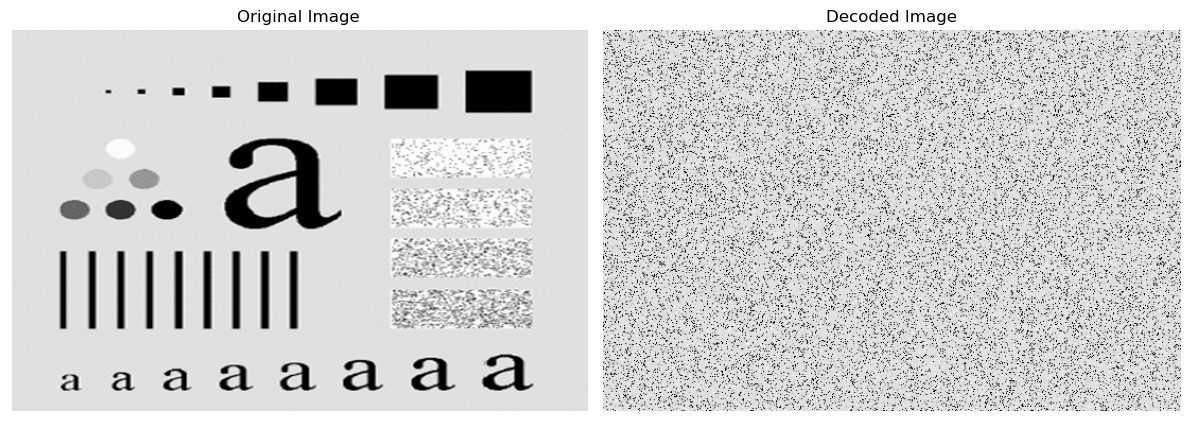

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Symbol probabilities
def calculate_probabilities(data):
    freq = {}
    for symbol in data:
        if symbol not in freq:
            freq[symbol] = 1
        else:
            freq[symbol] += 1
    total = len(data)
    probabilities = {symbol: freq[symbol] / total for symbol in freq}
    return probabilities

# Cumulative ranges for each symbol
def cumulative_probabilities(probabilities):
    symbols = sorted(probabilities)
    cum_prob = {}
    cumulative = 0.0
    for symbol in symbols:
        cum_prob[symbol] = (cumulative, cumulative + probabilities[symbol])
        cumulative += probabilities[symbol]
    return cum_prob

# Arithmetic encoding
def arithmetic_encode(data, cum_prob):
    low, high = 0.0, 1.0
    for symbol in data:
        range_ = high - low
        low = low + range_ * cum_prob[symbol][0]
        high = low + range_ * (cum_prob[symbol][1] - cum_prob[symbol][0])
    return (low + high) / 2  # Return the final number in the interval

# Arithmetic decoding
def arithmetic_decode(encoded_value, cum_prob, data_length):
    decoded_data = []
    for _ in range(data_length):
        for symbol, (low, high) in cum_prob.items():
            if low <= encoded_value < high:
                decoded_data.append(symbol)
                range_ = high - low
                encoded_value = (encoded_value - low) / range_
                break
    return decoded_data

# Compression ratio calculation
def calculate_compression_ratio(original_data, encoded_value):
    original_bits = len(original_data) * 8
    encoded_bits = encoded_value.bit_length() if hasattr(encoded_value, 'bit_length') else 64
    return original_bits / encoded_bits

def arithmetic_image_compression(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        print("Error loading image.")
        return

    flat_data = image.flatten().tolist()

    probs = calculate_probabilities(flat_data)
    cum_probs = cumulative_probabilities(probs)

    encoded_value = arithmetic_encode(flat_data, cum_probs)

    decoded_data = arithmetic_decode(encoded_value, cum_probs, len(flat_data))
    decoded_image = np.array(decoded_data, dtype=np.uint8).reshape(image.shape)

    compression_ratio = calculate_compression_ratio(flat_data, encoded_value)
    print(f"Compression Ratio: {compression_ratio:.2f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(image, cmap='gray')
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    axes[1].imshow(decoded_image, cmap='gray')
    axes[1].set_title("Decoded Image")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

image_path = "D:\\Code\\test_img.png"
arithmetic_image_compression(image_path)

MSE: 89.0591
PSNR: 28.63 dB


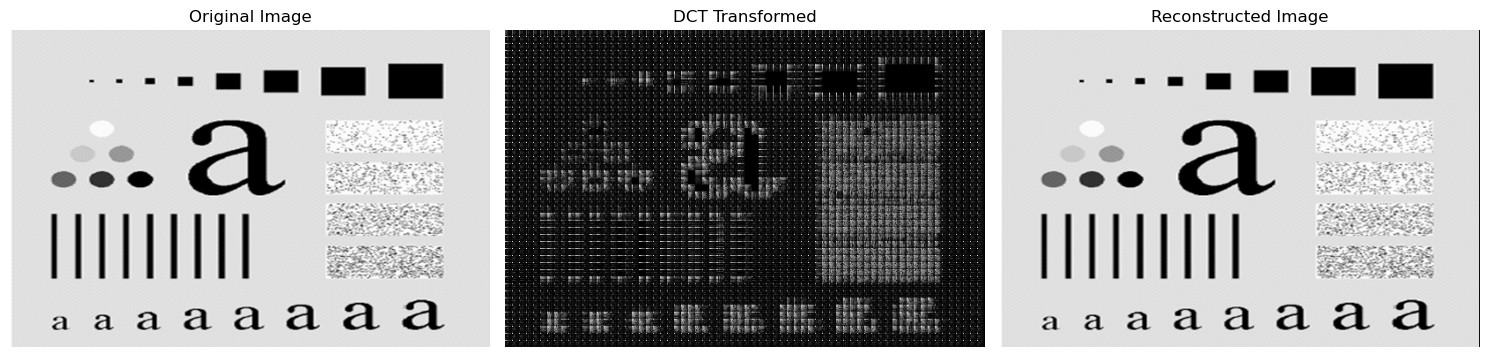

In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math

# 2D DCT
def dct2d(block):
    N = block.shape[0]
    M = block.shape[1]
    dct = np.zeros((N, M))
    for u in range(N):
        for v in range(M):
            sum_val = 0
            for x in range(N):
                for y in range(M):
                    sum_val += block[x, y] * \
                               math.cos((2*x + 1) * u * math.pi / (2 * N)) * \
                               math.cos((2*y + 1) * v * math.pi / (2 * M))
            alpha_u = math.sqrt(1 / N) if u == 0 else math.sqrt(2 / N)
            alpha_v = math.sqrt(1 / M) if v == 0 else math.sqrt(2 / M)
            dct[u, v] = alpha_u * alpha_v * sum_val
    return dct

# 2D Inverse DCT
def idct2d(dct_block):
    N = dct_block.shape[0]
    M = dct_block.shape[1]
    block = np.zeros((N, M))
    for x in range(N):
        for y in range(M):
            sum_val = 0
            for u in range(N):
                for v in range(M):
                    alpha_u = math.sqrt(1 / N) if u == 0 else math.sqrt(2 / N)
                    alpha_v = math.sqrt(1 / M) if v == 0 else math.sqrt(2 / M)
                    sum_val += alpha_u * alpha_v * dct_block[u, v] * \
                               math.cos((2*x + 1) * u * math.pi / (2 * N)) * \
                               math.cos((2*y + 1) * v * math.pi / (2 * M))
            block[x, y] = sum_val
    return block

def compute_mse(original, reconstructed):
    return np.mean((original - reconstructed) ** 2)

def compute_psnr(mse, max_pixel=255.0):
    if mse == 0:
        return float('inf')
    return 20 * math.log10(max_pixel / math.sqrt(mse))

def main():
    img = cv2.imread(r'D:\\Code\\test_img.png', cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Error: Image not found.")
        return

    img = img.astype(np.float64)
    height, width = img.shape

    # Apply DCT
    dct_img = np.zeros_like(img)
    for i in range(0, height, 8):
        for j in range(0, width, 8):
            block = img[i:i+8, j:j+8]
            if block.shape[0] == 8 and block.shape[1] == 8:
                dct_img[i:i+8, j:j+8] = dct2d(block)

    # Apply Inverse DCT
    reconstructed_img = np.zeros_like(img)
    for i in range(0, height, 8):
        for j in range(0, width, 8):
            block = dct_img[i:i+8, j:j+8]
            if block.shape[0] == 8 and block.shape[1] == 8:
                reconstructed_img[i:i+8, j:j+8] = idct2d(block)

    reconstructed_img = np.clip(reconstructed_img, 0, 255)
    reconstructed_img_uint8 = reconstructed_img.astype(np.uint8)

    mse = compute_mse(img, reconstructed_img)
    psnr = compute_psnr(mse)
    print(f"MSE: {mse:.4f}")
    print(f"PSNR: {psnr:.2f} dB")

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(np.log(np.abs(dct_img) + 1), cmap='gray')
    axes[1].set_title('DCT Transformed')
    axes[1].axis('off')

    axes[2].imshow(reconstructed_img_uint8, cmap='gray')
    axes[2].set_title('Reconstructed Image')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

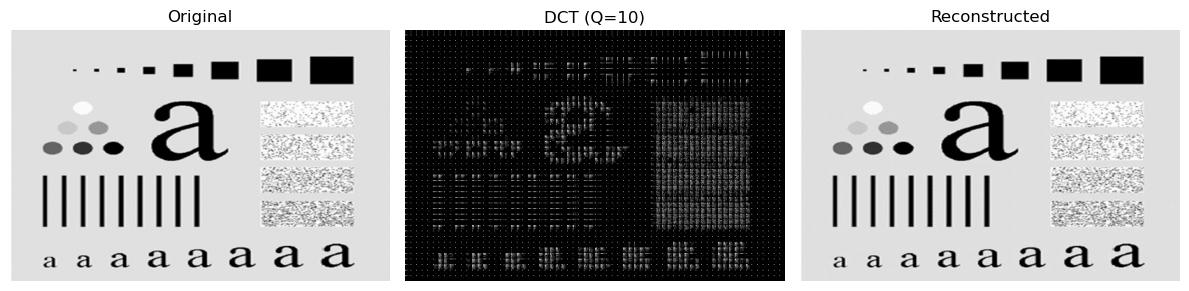

Quantization Factor: 10
Compression Ratio: 4.62
PSNR: 42.76 dB


In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import heapq
from collections import Counter

# Cosine Transform functions
def dct_2d(block):
    N = 8
    result = np.zeros((N, N))
    for u in range(N):
        for v in range(N):
            sum_ = 0.0
            for x in range(N):
                for y in range(N):
                    sum_ += block[x, y] * \
                            np.cos(((2 * x + 1) * u * np.pi) / (2 * N)) * \
                            np.cos(((2 * y + 1) * v * np.pi) / (2 * N))
            c_u = 1 / np.sqrt(2) if u == 0 else 1
            c_v = 1 / np.sqrt(2) if v == 0 else 1
            result[u, v] = 0.25 * c_u * c_v * sum_
    return result

# Inverse Cosine Transform functions
def idct_2d(block):
    N = 8
    result = np.zeros((N, N))
    for x in range(N):
        for y in range(N):
            sum_ = 0.0
            for u in range(N):
                for v in range(N):
                    c_u = 1 / np.sqrt(2) if u == 0 else 1
                    c_v = 1 / np.sqrt(2) if v == 0 else 1
                    sum_ += c_u * c_v * block[u, v] * \
                            np.cos(((2 * x + 1) * u * np.pi) / (2 * N)) * \
                            np.cos(((2 * y + 1) * v * np.pi) / (2 * N))
            result[x, y] = 0.25 * sum_
    return result

# Huffman coding functions
class Node:
    def __init__(self, symbol, freq):
        self.symbol = symbol
        self.freq = freq
        self.left = None
        self.right = None

    def __lt__(self, node):
        return self.freq < node.freq

# Build Huffman tree
def build_huffman_tree(freq):
    heap = [Node(symbol, f) for symbol, f in freq.items()]
    heapq.heapify(heap)

    while len(heap) > 1:
        n1 = heapq.heappop(heap)
        n2 = heapq.heappop(heap)
        merged = Node(None, n1.freq + n2.freq)
        merged.left, merged.right = n1, n2
        heapq.heappush(heap, merged)
    return heap[0]

# Generate Huffman codes
def build_code_table(node, prefix='', codebook={}):
    if node:
        if node.symbol is not None:
            codebook[node.symbol] = prefix
        build_code_table(node.left, prefix + '0', codebook)
        build_code_table(node.right, prefix + '1', codebook)
    return codebook

# Encode data using Huffman coding
def huffman_encode(data):
    freq = Counter(data)
    tree = build_huffman_tree(freq)
    codebook = build_code_table(tree)
    encoded = ''.join([codebook[val] for val in data])
    return encoded, tree, codebook

# Decode Huffman encoded data
def huffman_decode(encoded, tree):
    decoded = []
    node = tree
    for bit in encoded:
        node = node.left if bit == '0' else node.right
        if node.symbol is not None:
            decoded.append(node.symbol)
            node = tree
    return decoded

# Calculate PSNR
def psnr(original, reconstructed):
    mse = np.mean((original - reconstructed) ** 2)
    if mse == 0: return float('inf')
    return 20 * np.log10(255.0 / np.sqrt(mse))

# Load and preprocess image
def load_and_preprocess_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    h, w = img.shape
    img = img[:h - h % 8, :w - w % 8]
    img_shifted = img.astype(np.float32) - 128
    return img, img_shifted

# Apply DCT and quantization
def apply_dct_and_quantization(img_shifted, quant_factor):
    h, w = img_shifted.shape
    dct_image = np.zeros_like(img_shifted)
    for i in range(0, h, 8):
        for j in range(0, w, 8):
            block = img_shifted[i:i+8, j:j+8]
            dct_block = dct_2d(block)
            quantized = np.round(dct_block / quant_factor)
            dct_image[i:i+8, j:j+8] = quantized
    return dct_image

# Compress using Huffman coding
def compress_with_huffman(dct_image):
    flat_quantized = dct_image.flatten().astype(np.int32)
    encoded_data, tree, codebook = huffman_encode(flat_quantized.tolist())
    return encoded_data, tree, dct_image.shape

# Decompress using Huffman coding
def decompress_with_huffman(encoded_data, tree, shape):
    decoded_flat = huffman_decode(encoded_data, tree)
    decoded_quantized = np.array(decoded_flat, dtype=np.float32).reshape(shape)
    return decoded_quantized

# Reconstruct image from quantized DCT coefficients
def reconstruct_image(decoded_quantized, quant_factor):
    h, w = decoded_quantized.shape
    reconstructed = np.zeros((h, w), dtype=np.float32)
    for i in range(0, h, 8):
        for j in range(0, w, 8):
            block = decoded_quantized[i:i+8, j:j+8] * quant_factor
            idct_block = idct_2d(block)
            reconstructed[i:i+8, j:j+8] = idct_block + 128
    return np.clip(reconstructed, 0, 255).astype(np.uint8)

# Compute compression ratio and PSNR
def compute_metrics(original, reconstructed, encoded_data):
    original_bits = original.size * 8
    compressed_bits = len(encoded_data)
    compression_ratio = original_bits / compressed_bits
    psnr_value = psnr(original, reconstructed)
    return compression_ratio, psnr_value

def plot_results(original, dct_image, reconstructed, quant_factor):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.title("Original")
    plt.imshow(original, cmap='gray')
    plt.axis('off')
    plt.subplot(1, 3, 2)
    plt.title(f"DCT (Q={quant_factor})")
    plt.imshow(np.log1p(np.abs(dct_image)), cmap='gray')
    plt.axis('off')
    plt.subplot(1, 3, 3)
    plt.title("Reconstructed")
    plt.imshow(reconstructed, cmap='gray')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

def main():
    image_path = "D:\\Code\\test_img.png"
    quant_factor = 10

    original, img_shifted = load_and_preprocess_image(image_path)
    dct_image = apply_dct_and_quantization(img_shifted, quant_factor)
    encoded_data, tree, shape = compress_with_huffman(dct_image)
    decoded_quantized = decompress_with_huffman(encoded_data, tree, shape)
    reconstructed = reconstruct_image(decoded_quantized, quant_factor)
    compression_ratio, psnr_value = compute_metrics(original, reconstructed, encoded_data)
    plot_results(original, dct_image, reconstructed, quant_factor)

    print(f"Quantization Factor: {quant_factor}")
    print(f"Compression Ratio: {compression_ratio:.2f}")
    print(f"PSNR: {psnr_value:.2f} dB")

if __name__ == "__main__":
    main()